# K-Means Clustering

#### 1. Load the data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Using same dataset as of Earlier Dataset
df = pd.read_csv("../ML Data.csv", dtype = {'ROLL NO.': str})
df.columns = df.columns.str.strip() # headers had extra spaces again, annoying but easy fix

# Here df.columns gets the list of Column Names
#.str lets you apply string operations to all column names at once
#.strip() removes leading/trailing White Spaces from each name
#df.columns reassigns the cleaned names Back onto the Dataframe

print (df.head())
print (df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [20]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

# not really needed for clustering since we're not using RESULT/GRADE as features
# but cleaning them anyway in case we want to compare clusters against them later
df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

# filling missing marks with the mean, missing categories with the mode, nothing special here
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])  # a row with no id isn't really usable anyway
print(df.isnull().sum())
print(df.shape)

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64
(71, 9)


#### 3. Select features for clustering
K-Means is unsupervised so there's no target column here, just grouping students by their marks.

In [21]:
# just grabbing the 5 subject columns, that's all we need for this
X = df[numeric_cols]
X.head()

,SOFTWARE ENGINEER,TOC,COMPUTER NETWORK,MACHINE LEARNING,DATA WAREHOUSE
0,30.0,30.0,30.0,30.0,30.0
1,30.0,40.0,45.0,40.0,35.0
2,38.0,38.0,38.0,38.0,38.0
3,59.0,55.0,57.0,58.0,54.0
4,30.0,30.0,30.0,30.0,30.0


#### 4. Feature scaling
K-Means uses distance between points to form clusters, so if one subject has a bigger range of marks than the others it would basically dominate the clustering. Scaling puts everything on equal footing.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# not converting back to a dataframe here, kmeans is fine with the numpy array directly

#### 5. Find the right number of clusters (Elbow Method)
We don't actually know how many groups makes sense beforehand, so this loop tries a bunch of k values and we look for the point where adding more clusters stops helping much (the 'elbow').

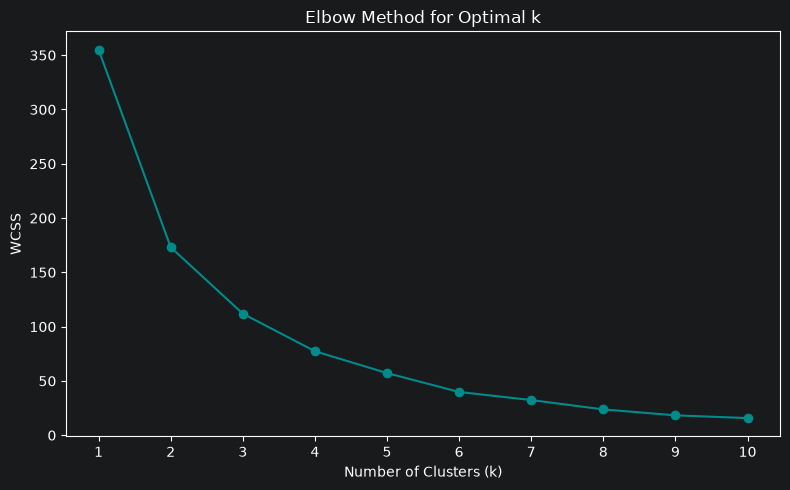

In [23]:
from sklearn.cluster import KMeans

wcss = []  # within-cluster sum of squares, basically how tight the clusters are
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)  # inertia = wcss basically, sklearn just calls it that

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', color='darkcyan')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

# eyeball the plot above and see where the curve stops dropping sharply, thats roughly the best k

#### 6. Confirm k using Silhouette Score
The elbow plot is a bit subjective (kind of a judgement call tbh), so silhouette score gives an actual number to back it up. Closer to 1 = better separated clusters.

k = 2: silhouette score = 0.5033
k = 3: silhouette score = 0.5229
k = 4: silhouette score = 0.4851
k = 5: silhouette score = 0.4942
k = 6: silhouette score = 0.4950
k = 7: silhouette score = 0.5039
k = 8: silhouette score = 0.4735
k = 9: silhouette score = 0.4676
k = 10: silhouette score = 0.4037


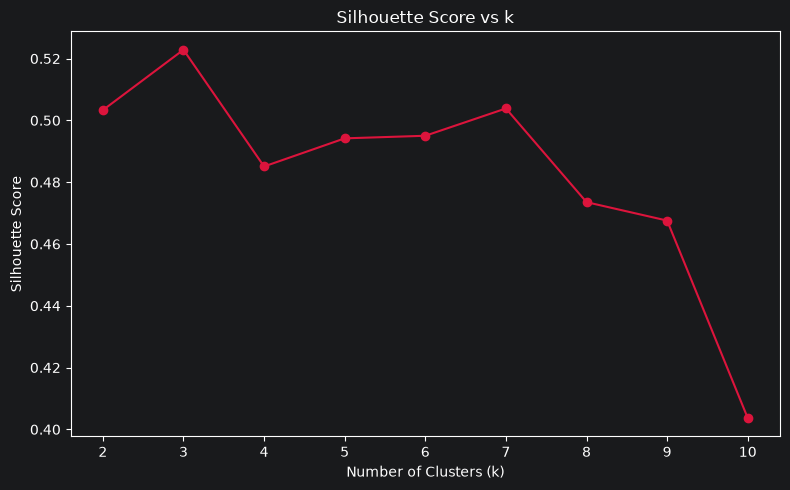


best k according to silhouette score: 3


In [24]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette needs at least 2 clusters, cant check k=1

for k in k_range_sil:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f"k = {k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), silhouette_scores, marker='o', color='crimson')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_range_sil)[np.argmax(silhouette_scores)]
print(f"\nbest k according to silhouette score: {best_k}")

#### 7. Fit the final K-Means model
Using whatever k came out best from the silhouette check above.

In [25]:
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# sticking the cluster number back onto the original dataframe so we can look at it properly
df['CLUSTER'] = cluster_labels
print(df['CLUSTER'].value_counts())

CLUSTER
1    37
0    32
2     2
Name: count, dtype: int64


#### 8. Visualize the clusters
We have 5 features so we can't just plot it directly, using PCA to squash it down to 2D just for visualization purposes (not changing the actual clustering, just makes it easier to look at).

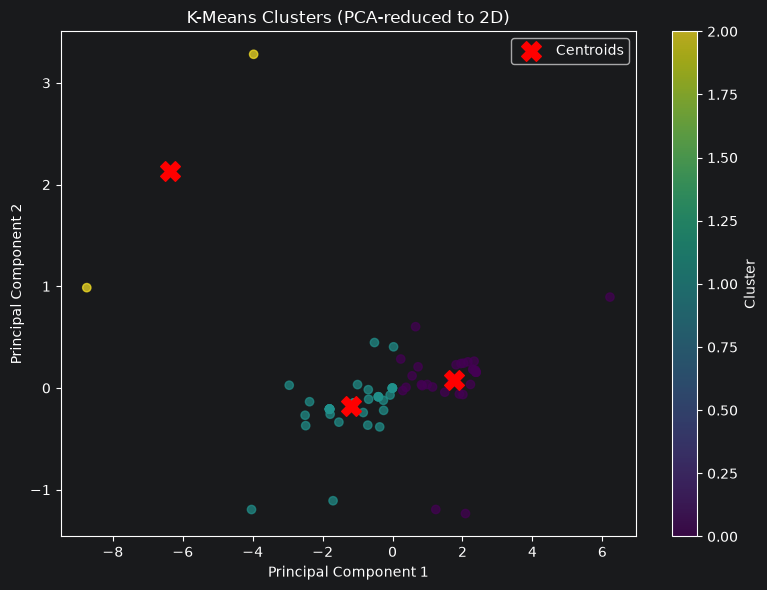

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)

# also plotting the centroids so we can see where kmeans thinks the "middle" of each group is
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('K-Means Clusters (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

#### 9. Look at what each cluster actually represents
Averaging the marks within each cluster to get a sense of whether it grouped high scorers, low scorers, etc. together.

         SOFTWARE ENGINEER        TOC  COMPUTER NETWORK  MACHINE LEARNING  \
CLUSTER                                                                     
0                 54.12500  55.531250         56.187500         56.718750   
1                 33.82194  35.224165         33.607313         35.424483   
2                 -5.00000  -9.500000         -6.500000        -28.500000   

         DATA WAREHOUSE  
CLUSTER                  
0             55.437500  
1             34.379968  
2             32.500000  


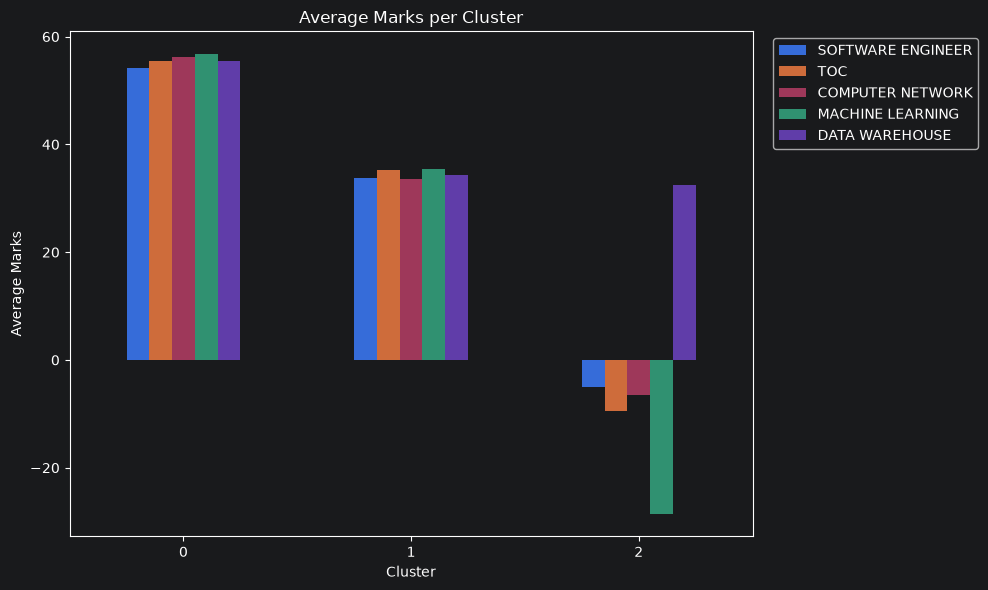

In [29]:
cluster_profile = df.groupby('CLUSTER')[numeric_cols].mean()
print(cluster_profile)

# quick bar chart so its easier to compare clusters at a glance instead of just staring at numbers
cluster_profile.plot(kind='bar', figsize=(10, 6))
plt.title('Average Marks per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Marks')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 10. Sanity check against RESULT
Not something kmeans was told about (its unsupervised, doesnt know about pass/fail), but interesting to see if the clusters roughly line up with actual results anyway.

In [30]:
# just a cross tab, nothing complicated, checking if certain clusters lean pass or fail
print(pd.crosstab(df['CLUSTER'], df['RESULT']))

RESULT   DISCHARGE  FAIL  PASS
CLUSTER                       
0                0     0    32
1                0     3    34
2                1     1     0
